#### SPHEREx confirms predictions for artificial satellite trail pollution in Low Earth Orbit
Author: Alejandro S. Borlaff - NASA Ames Research Center
Space Science and Astrobiology Division. April 2026.

In this article we measure the number of artificial satellite trails appearing in a series of astronomical images obtained by the NASA SPHEREx space telescope, a near-infrared low Earth orbit observatory dedicated to the creation of an all-sky survey of 450 million galaxies. The following notebook produces the main plots generated in the article, which compare the satellite trail simulations based on Borlaff, Marcum and Howell (2025, Nature) with the observations of satellite trails from this article. 

For publication in the Astronomical Journal.

Data and code available on Zenodo. https://doi.org/10.5281/zenodo.17957748

Dependencies:

Python==3.10

rosalia-wfi: https://pypi.org/project/rosalia-wfi/

bootmedian: https://pypi.org/project/Bootmedian/

ipykernel: conda install -n empty ipykernel --update-deps --force-reinstall

pandas: https://pandas.pydata.org/

numpy: https://numpy.org/

astropy: https://www.astropy.org/


In [1]:
import numpy as np
import pandas as pd
import rosalia as rs
import bootmedian as bm
import matplotlib.pyplot as plt

# Style imports
import matplotlib
matplotlib.rcParams['pdf.fonttype']=42

# Fixing random seed
import random
random.seed(123)
spherex_color = '#046b99'

In [2]:
# Reading Planet4589 database for the number of active satellites in orbit as a function of time.
active_satellite_vs_time_db = pd.read_csv("https://planet4589.org/space/stats/out/stat001.txt", sep="\s+",
                                          skiprows=1, header=None)

nsats_in_orbit = active_satellite_vs_time_db[11] - active_satellite_vs_time_db[8]  - active_satellite_vs_time_db[7]  - active_satellite_vs_time_db[6]
tsats_in_orbit = active_satellite_vs_time_db[1]

sats_in_2000 = np.mean(nsats_in_orbit[(tsats_in_orbit>2000) & (tsats_in_orbit < 2001)])
sats_in_2016 = np.mean(nsats_in_orbit[(tsats_in_orbit>2016) & (tsats_in_orbit < 2017)])
sats_in_2020 = np.mean(nsats_in_orbit[(tsats_in_orbit>2020) & (tsats_in_orbit < 2021)])
sats_in_2022 = np.mean(nsats_in_orbit[(tsats_in_orbit>2022) & (tsats_in_orbit < 2023)])
sats_in_may2025 = np.mean(nsats_in_orbit[(tsats_in_orbit>2025+5/12) & (tsats_in_orbit < 2025+6/12)])
sats_in_sept2025 = np.mean(nsats_in_orbit[(tsats_in_orbit>2025+9/12) & (tsats_in_orbit < 2025+10/12)])

In [12]:
from astropy.table import Table
import astropy.units as u
import pandas as pd
all_trails_db = pd.read_csv("SPHEREx_trails_database.csv")

t = Table.from_pandas(all_trails_db)

t["ra"] = t["ra"]*u.degree
t["dec"] = t["dec"]*u.degree
t["pa"] = t["pa"]*u.degree
t["SGT_LAT_MIDPT"] = t["SGT_LAT_MIDPT"]*u.degree
t["SGT_LON_MIDPT"] = t["SGT_LON_MIDPT"]*u.degree
t["SGT_MIN_GCD2SAA"] = t["SGT_MIN_GCD2SAA"]*u.degree
t["SPS_ELON"] = t["SPS_ELON"]*u.degree
t["SPS_ELAT"] = t["SPS_ELAT"]*u.degree
t["SPS_EPA"] = t["SPS_EPA"]*u.degree
t["XPOSURE"] = t["XPOSURE"]*u.second

t.write('SPHEREx_trails_database.mrt', format='ascii.mrt')

In [3]:
# Reading SPHEREx trail databases
# Observational databases
all_trails_db = pd.read_csv("SPHEREx_trails_database.csv")
trails_per_image_db =  pd.read_csv("SPHEREx_trails_per_exp_database.csv")

# Extracting the number of trails per image for the SPHEREx observational database
n_trails = np.array(trails_per_image_db["ntrails"])

# Simulation database
spherex_per_trail_db=pd.read_csv("SPHEREx_per_trail_database.csv")
spherex_per_sim_db=pd.read_csv("SPHEREx_per_sim_database.csv")
spherex_per_bin_db=pd.read_csv("SPHEREx_per_bin_database.csv")

hst_per_trail_db=pd.read_csv("HST_per_trail_database.csv")
hst_per_sim_db=pd.read_csv("HST_per_sim_database.csv")
hst_per_bin_db=pd.read_csv("HST_per_bin_database.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'SPHEREx_trails_per_exp_database.csv'

In [ ]:
kruk_borlaff_db

,Unnamed: 0,nsats,hst_san_ntrails
0,0,1.0,0.000021
1,1,2.0,0.000040
2,2,3.0,0.000061
3,3,4.0,0.000081
4,4,5.0,0.000092
...,...,...,...
1843079,1843079,1843080.0,20.541311
1843080,1843080,1843081.0,20.541328
1843081,1843081,1843082.0,20.541339
1843082,1843082,1843083.0,20.541350


In [5]:
# Estimating the percentage of images with at least one trail, and its confidence interval using bootmedian.
std = (np.zeros(n_trails.shape)+0.43)/len(n_trails)*100
images_with_at_least_one_trail = bm.bootmedian(sample_input=(n_trails > 0)/len(n_trails)*100, std=std, mode="sum")
print("N trails with at least one trail: " + str(images_with_at_least_one_trail["median"]) + "+" +\
      str(images_with_at_least_one_trail["s1_up"] - images_with_at_least_one_trail["median"]) +\
      str(images_with_at_least_one_trail["s1_down"] - images_with_at_least_one_trail["median"]) + "%")

N trails with at least one trail: 73.6934435361002+2.213350470230907-2.420767720090396%


{'median': 2.19649489856537, 's1_up': 2.3185760754412876, 's1_down': 2.0928618212400547, 's2_up': 2.4193128256846994, 's2_down': 2.0081736336697555, 's3_up': 2.4815709796710257, 's3_down': 1.9147578129825598, 'std1_up': 4.0, 'std1_down': 0.0, 'sims': [2.3868164884321557, 2.354399861511659, 2.283495105178178, 2.3933390438054953, 2.0331829867048508, 2.4193128256846994, 2.220997534614147, 2.135998241340031, 2.274610695115672, 2.377613003144668, 2.039655219662645, 2.1950359002189925, 2.162148888056438, 2.264437392370132, 2.248872258509296, 2.052336254663296, 2.302784960679647, 2.187062514459055, 2.1489964313713954, 2.134388789118514, 2.2188003430193097, 2.12713116083712, 2.1610394084013476, 2.3185760754412876, 2.139252592359898, 2.093805172813837, 2.1280769764220007, 2.144443476192157, 2.3868164884321557, 2.354399861511659, 2.283495105178178, 2.3933390438054953, 2.0331829867048508, 2.4193128256846994, 2.220997534614147, 2.135998241340031, 2.274610695115672, 2.377613003144668, 2.03965521966

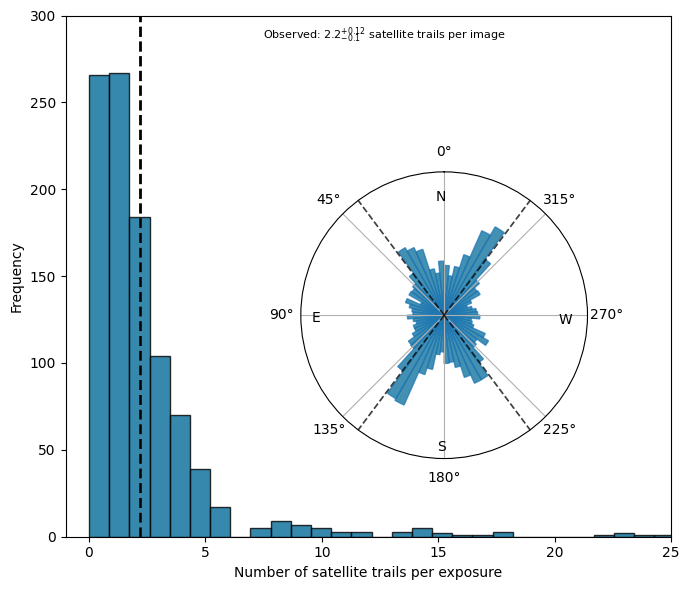

In [6]:
# Plotting the histogram of the number of trails per image, and the distribution of their position angles.
fig, ax = plt.subplots(figsize=(7,6))
ax.hist(n_trails, bins=30, color=spherex_color, edgecolor="black", alpha=0.8, density=False)
mean_trails = bm.bootmedian(n_trails, std=np.zeros(n_trails.shape) + 0.43, mode="mean")

mean_label = r'Observed: ' + str(np.round(mean_trails["median"], 2)) +\
             '$^{+' + str(np.round(mean_trails["s1_up"] - mean_trails["median"], 2)) + '}'+\
             '_{' + str(np.round(mean_trails["s1_down"] - mean_trails["median"], 2)) + '}$ satellite trails per image'

ax.axvline(mean_trails["median"], linewidth=2, linestyle="--", color="white", label=mean_label)
ax.axvline(mean_trails["median"], linewidth=2, linestyle="--", color="black")
ax.set_ylabel("Frequency")
ax.set_xlabel("Number of satellite trails per exposure")
print(mean_trails)

# Add the inset axes 
ins = ax.inset_axes([0.35,0.15,0.55,0.55], projection='polar')

median_sat_inclination = (90-53.16)*np.pi/180
ins.plot([median_sat_inclination, median_sat_inclination], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([-median_sat_inclination, -median_sat_inclination], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([-median_sat_inclination+np.pi, -median_sat_inclination+np.pi], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([median_sat_inclination+np.pi,  median_sat_inclination+np.pi], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")

rs.utils.circular_hist(ins, all_trails_db["pa"]*np.pi/180, offset=np.pi/2, density=True, bins=60, color=spherex_color)

ins.set_rmax(0.2)
ins.text(0.075, 0.16,  'N')
ins.text(np.pi-0.05, 0.19,  'S')
ins.text(np.pi/2+0.05, 0.185,  'E')
ins.text(3*np.pi/2-0.075, 0.16,  'W')
ax.set_xlim(-1,25)
ax.set_ylim(0,300)


ax.legend(frameon=False, loc='upper center', prop={'size': 8})
plt.tight_layout()
plt.savefig("hist_spherex_trails.jpeg", dpi=600)

{'median': 2.2162902494330963, 's1_up': 2.4036281179138324, 's1_down': 2.0634920634920637, 's2_up': 2.5419501133786846, 's2_down': 1.784580498866213, 's3_up': 2.619047619047619, 's3_down': 1.782312925170068, 'std1_up': 0, 'std1_down': 0, 'sims': [2.249433106575964, 2.310657596371882, 2.195011337868481, 2.077097505668934, 2.2312925170068025, 2.4467120181405897, 2.165532879818594, 2.072562358276644, 2.1746031746031744, 2.2653061224489797, 2.122448979591837, 2.1405895691609977, 1.784580498866213, 2.310657596371882, 2.0929705215419503, 2.4285714285714284, 2.4761904761904763, 2.2675736961451247, 1.8843537414965987, 1.9886621315192743, 2.2879818594104306, 2.494331065759637, 2.2312925170068025, 2.4489795918367347, 2.0816326530612246, 2.17687074829932, 2.163265306122449, 1.9909297052154196, 2.249433106575964, 2.310657596371882, 2.195011337868481, 2.077097505668934, 2.2312925170068025, 2.4467120181405897, 2.165532879818594, 2.072562358276644, 2.1746031746031744, 2.2653061224489797, 2.1224489795

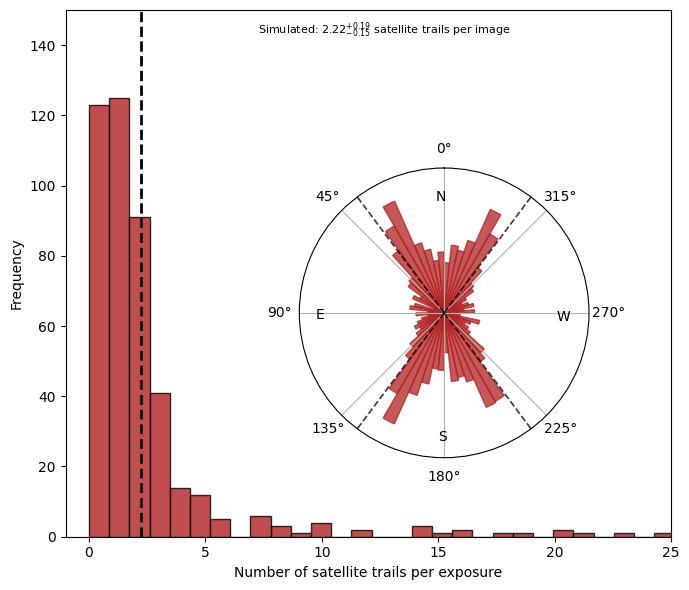

In [7]:
# Now plotting the same for the SPHEREx simulation database, for 20000 satellites in orbit, which is the number of satellites in orbit at the time of the SPHEREx survey.
spherex_sim_pa = spherex_per_trail_db["pa_trail"][spherex_per_trail_db["nsats"] == 20000]
n_trails_sim = spherex_per_sim_db["crossing_trails"][spherex_per_sim_db["nsats_per_sim"] == 20000]

import random
for i in range(len(spherex_sim_pa)):
    k = random.randint(0, 10) # decide on k once
    spherex_sim_pa.iloc[i] = spherex_sim_pa.iloc[i] + 180*k 
    

fig, ax = plt.subplots(figsize=(7,6))
ax.hist(n_trails_sim, bins=30, color="firebrick", edgecolor="black", alpha=0.8, density=False)
mean_trails = bm.bootmedian(np.array(n_trails_sim), mode="mean")

mean_label = r'Simulated: ' + str(np.round(mean_trails["median"], 2)) +\
             '$^{+' + str(np.round(mean_trails["s1_up"] - mean_trails["median"], 2)) + '}'+\
             '_{' + str(np.round(mean_trails["s1_down"] - mean_trails["median"], 2)) + '}$ satellite trails per image'

ax.axvline(mean_trails["median"], linewidth=2, linestyle="--", color="white", label=mean_label)
ax.axvline(mean_trails["median"], linewidth=2, linestyle="--", color="black")
ax.set_ylabel("Frequency")
ax.set_xlabel("Number of satellite trails per exposure")
print(mean_trails)
ax.set_xlim(-1,25)
ax.set_ylim(0,150)
# Add the inset axes 
ins = ax.inset_axes([0.35,0.15,0.55,0.55], projection='polar')

median_sat_inclination = (90-53.16)*np.pi/180
ins.plot([median_sat_inclination, median_sat_inclination], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([-median_sat_inclination, -median_sat_inclination], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([-median_sat_inclination+np.pi, -median_sat_inclination+np.pi], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
ins.plot([median_sat_inclination+np.pi,  median_sat_inclination+np.pi], [0, 1], linestyle="--", linewidth=1.25, alpha=0.75, color="black")
rs.utils.circular_hist(ins, spherex_sim_pa*np.pi/180, offset=np.pi/2, density=True, bins=60, color="firebrick", edgecolor="firebrick")
# plt.legend()

ins.set_rmax(0.18)
ins.text(0.075, 0.14,  'N')
ins.text(np.pi-0.05, 0.16,  'S')
ins.text(np.pi/2+0.05, 0.16,  'E')
ins.text(3*np.pi/2-0.075, 0.14,  'W')


ax.legend(frameon=False, loc='upper center', prop={'size': 8})
plt.tight_layout()

plt.savefig("hist_spherex_trails_sim.jpeg", dpi=600)

In [8]:
# KS test for the number of satellites 
from scipy.stats import ks_2samp
ks_2samp(n_trails, n_trails_sim, alternative='two-sided', method='auto', axis=0, nan_policy='propagate', keepdims=False)

KstestResult(statistic=0.05170748299319728, pvalue=0.3707465083535527, statistic_location=2.0, statistic_sign=-1)

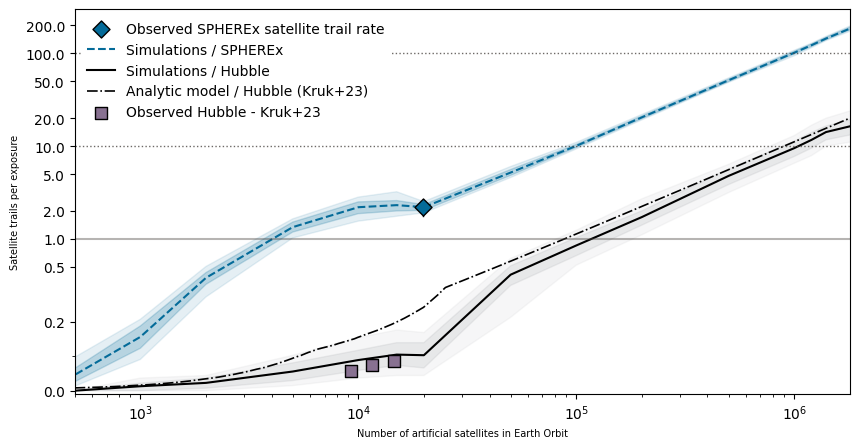

In [9]:
# Plotting the trends of the number of trails per image as a function of the number of satellites in orbit, for the SPHEREx and Hubble missions, and comparing with Hubble simulations and observations.

from matplotlib.ticker import ScalarFormatter

active_satellite_vs_time_db = pd.read_csv("https://planet4589.org/space/stats/out/stat001.txt", sep='\s+',
                                          skiprows=1, header=None)

fig, ax = plt.subplots(figsize=(10,5)) # figsize=(7.204724,3)

hubble_color = '#aeb0b5'
spherex_color = '#046b99'

####################

# SPHEREx observations
mean_sats = 19884 #(sats_in_may2025+sats_in_sept2025)/2

ax.plot([19000,20000], [mean_trails["median"], mean_trails["median"]], color="black", linewidth=2)
ax.plot([mean_sats, mean_sats], [mean_trails["s1_down"], mean_trails["s1_up"]], color="black", linewidth=2)
ax.plot([mean_sats, mean_sats], [mean_trails["s2_down"], mean_trails["s2_up"]], color="black", linewidth=1)
ax.plot([mean_sats, mean_sats], [mean_trails["s3_down"], mean_trails["s3_up"]], color="black", linewidth=0.5)

ax.scatter(mean_sats, mean_trails["median"], marker="D", edgecolor="black", s=75, color=spherex_color, zorder=999, label="Observed SPHEREx satellite trail rate")

##########################


nsats_list = np.array(spherex_per_bin_db.columns, dtype=float) 
db_ntrails_vs_nsats = pd.DataFrame({"nsats": nsats_list})


spherex_ntrails_per_bin        = spherex_per_bin_db.iloc[0,:]
spherex_ntrails_per_bin_s2up   = spherex_per_bin_db.iloc[1,:]
spherex_ntrails_per_bin_s2down = spherex_per_bin_db.iloc[2,:]
spherex_ntrails_per_bin_s3up   = spherex_per_bin_db.iloc[3,:]
spherex_ntrails_per_bin_s3down = spherex_per_bin_db.iloc[4,:]

db_ntrails_vs_nsats["mean_ntrails_SPHEREx"] = spherex_ntrails_per_bin
db_ntrails_vs_nsats["c95_up_ntrails_SPHEREx"] = spherex_ntrails_per_bin_s2up
db_ntrails_vs_nsats["c95_down_ntrails_SPHEREx"] = spherex_ntrails_per_bin_s2down

ax.plot(nsats_list, spherex_ntrails_per_bin, color=spherex_color,
        markerfacecolor=spherex_color, label = "Simulations / SPHEREx", linestyle="--")
ax.fill_between(nsats_list, spherex_ntrails_per_bin_s2up, spherex_ntrails_per_bin_s2down, color=spherex_color, alpha=0.2)
ax.fill_between(nsats_list, spherex_ntrails_per_bin_s3up, spherex_ntrails_per_bin_s3down, color=spherex_color, alpha=0.1)


##########################

nsats_list = np.array(hst_per_bin_db.columns, dtype=float)
hst_ntrails_per_bin = np.array(hst_per_bin_db.iloc[0,:])
hst_ntrails_per_bin_s2up = np.array(hst_per_bin_db.iloc[1,:])
hst_ntrails_per_bin_s2down = np.array(hst_per_bin_db.iloc[2,:])
hst_ntrails_per_bin_s3up = np.array(hst_per_bin_db.iloc[3,:])
hst_ntrails_per_bin_s3down = np.array(hst_per_bin_db.iloc[4,:])
ax.plot(nsats_list, hst_ntrails_per_bin, color='black', label="Simulations / Hubble")
ax.fill_between(nsats_list, hst_ntrails_per_bin_s2up, hst_ntrails_per_bin_s2down, color=hubble_color, alpha=0.2)
ax.fill_between(nsats_list, hst_ntrails_per_bin_s3up, hst_ntrails_per_bin_s3down, color=hubble_color, alpha=0.1)

db_ntrails_vs_nsats["mean_ntrails_HST"] = hst_ntrails_per_bin
db_ntrails_vs_nsats["c95_up_ntrails_HST"] = hst_ntrails_per_bin_s2up
db_ntrails_vs_nsats["c95_down_ntrails_HST"] = hst_ntrails_per_bin_s2down

####################################
# Current observations simulations #
####################################
kruk_borlaff_db = pd.read_csv("kruk_borlaff_26_db.csv")

ax.plot(kruk_borlaff_db["nsats"], kruk_borlaff_db["hst_san_ntrails"], color="black",linewidth=1.2,
        markerfacecolor="black", label = "Analytic model / Hubble (Kruk+23)", linestyle="-.")


sats_in_2000 = np.mean(nsats_in_orbit[(tsats_in_orbit>2000) & (tsats_in_orbit < 2001)])

sats_in_kruk_2002_2005 = np.mean(nsats_in_orbit[(tsats_in_orbit>2002) & (tsats_in_orbit < 2005+1)])
sats_in_kruk_2015 = np.mean(nsats_in_orbit[(tsats_in_orbit>2015) & (tsats_in_orbit < 2015+1)])
sats_in_kruk_2018_2021 = np.mean(nsats_in_orbit[(tsats_in_orbit>2018) & (tsats_in_orbit < 2021+1)])

# This contains the values obtained by Kruk et al. 2023. 
ax.scatter(sats_in_kruk_2002_2005, 2.8/100*2, marker="s", edgecolor="black", s=75, color="xkcd:greyish purple", zorder=998,
           label="Observed Hubble - Kruk+23")
ax.plot([sats_in_kruk_2002_2005,sats_in_kruk_2002_2005], [(2.8-0.2)/100*2, (2.8+0.2)/100*2], linewidth=1.5)

ax.scatter(sats_in_kruk_2018_2021, 4.3/100*2, marker="s", edgecolor="black", s=75, zorder=997, color="xkcd:greyish purple")
ax.plot([sats_in_kruk_2018_2021,sats_in_kruk_2018_2021], [(4.3-0.4)/100*2,(4.3+0.4)/100*2], linewidth=1.5)

ax.scatter(sats_in_kruk_2015, 3.75/100*2, marker="s", edgecolor="black", s=75, zorder=997, color="xkcd:greyish purple")
ax.plot([sats_in_kruk_2015,sats_in_kruk_2015], [(3.75-0.5)/100*2,(3.75+0.5)/100*2], linewidth=1.5)


##########################

ax.axhline(y=1, linestyle="-", color="#494440", alpha=0.4)
ax.axhline(y=10, linestyle=":", linewidth=1, color="#494440", alpha=0.8)
ax.axhline(y=100, linestyle=":", linewidth=1, color="#494440", alpha=0.8)
ax.set_xscale("log")
ax.set_ylim(-0.01,300)
ax.set_xlim(500,1800000)
ax.set_xlabel("Number of artificial satellites in Earth Orbit", size=7)
ax.set_ylabel("Satellite trails per exposure", size=7)
ax.set_yscale("symlog", linthresh=0.3)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0,0.2,0.5,1,2,5,10,20,50,100,200])


leg = ax.legend(loc="upper left", ncol=1, frameon=True, framealpha=1)
leg.get_frame().set_edgecolor('white')

plt.savefig("obs_spherex_ntrails_vs_nsats.pdf",  dpi=600, format="pdf", bbox_inches='tight')
plt.show()

db_ntrails_vs_nsats.to_csv("ntrails_vs_nsats_table.csv")

In [19]:
np.nanmedian(spherex_per_trail_db["altitude_satellites"])


1992775.6441887468